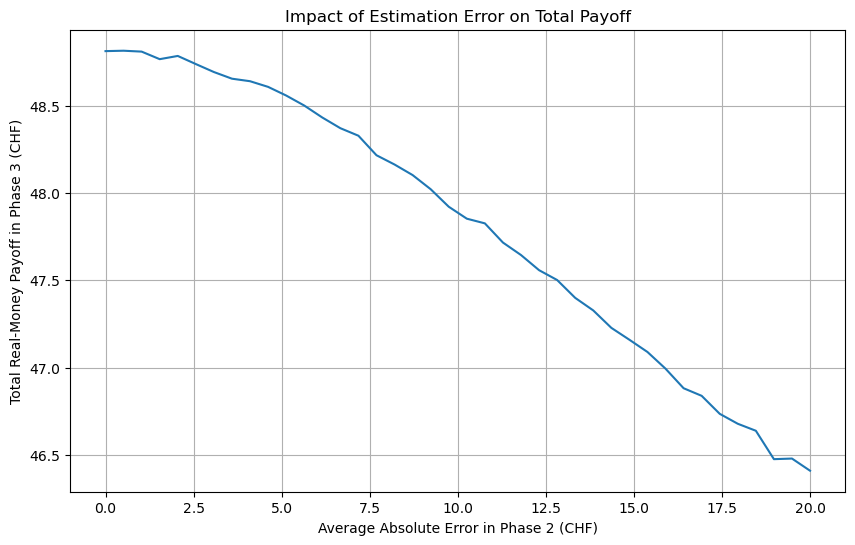

    Error Level  Total Payoff (CHF)
0      0.000000           48.813686
1      0.512821           48.815979
2      1.025641           48.810860
3      1.538462           48.767575
4      2.051282           48.786043
5      2.564103           48.739502
6      3.076923           48.693821
7      3.589744           48.655612
8      4.102564           48.641175
9      4.615385           48.608774
10     5.128205           48.559147
11     5.641026           48.501780
12     6.153846           48.433139
13     6.666667           48.371854
14     7.179487           48.328699
15     7.692308           48.216795
16     8.205128           48.163606
17     8.717949           48.103116
18     9.230769           48.022030
19     9.743590           47.921666
20    10.256410           47.853172
21    10.769231           47.826268
22    11.282051           47.716318
23    11.794872           47.644732
24    12.307692           47.557876
25    12.820513           47.501523
26    13.333333           47

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
true_values = np.linspace(2, 42, 23)  # 23 unique gabor values
n_trials_phase3 = 184
n_simulations = 1000  # Number of simulations per error level

# Function to simulate Phase 3 auction
def simulate_auction(true_values, estimated_values):
    payoffs = []
    for true_val, est_val in zip(true_values, estimated_values):
        random_price = np.random.uniform(2, 42)
        if est_val >= random_price:
            payoff = true_val - random_price + 42
        else:
            payoff = 42
        payoffs.append(payoff)
    return np.sum(payoffs)  # Total payoff across all trials (no division by n_trials_phase3)

# Simulate for different error levels
error_levels = np.linspace(0, 20, 40)  # Average absolute error from 0 to 20
avg_payoffs = []

for error in error_levels:
    payoffs = []
    for _ in range(n_simulations):
        # Each of the 23 gabors appears exactly 8 times
        sampled_true_values = np.repeat(true_values, repeats=n_trials_phase3 // len(true_values))
        estimated_values = sampled_true_values + np.random.normal(0, error, size=n_trials_phase3)
        estimated_values = np.clip(estimated_values, 2, 42)  # Ensure values are within bounds

        # Simulate auction payoff
        total_payoff = simulate_auction(sampled_true_values, estimated_values)
        scaled_payoff = total_payoff / 184  # Scale total payoff by 1/184
        payoffs.append(scaled_payoff)
    avg_payoffs.append(np.mean(payoffs))

# Plot results
plt.figure(figsize=(10, 6))
sns.lineplot(x=error_levels, y=avg_payoffs)
plt.xlabel("Average Absolute Error in Phase 2 (CHF)")
plt.ylabel("Total Real-Money Payoff in Phase 3 (CHF)")
plt.title("Impact of Estimation Error on Total Payoff")
plt.grid(True)
plt.show()

# Print results
results = pd.DataFrame({"Error Level": error_levels, "Total Payoff (CHF)": avg_payoffs})
print(results)


In [7]:
estimated_values

array([ 6.81278996, 14.11502399,  2.        , 42.        , 24.93804063,
        2.        , 17.52524136, 18.74890275,  4.41762128, 21.52529056,
       41.0055149 , 42.        ,  9.752344  , 22.45249857, 27.93527874,
       42.        , 17.28882588, 42.        , 42.        , 40.52544836,
       42.        ,  2.        ,  2.        ])

In [3]:
payoff

2.7359827304107167

In [15]:
V = np.linspace(2, 42, 23)
sampled_V = np.repeat(V, repeats=8)  # Each gabor appears 8 times
expected_profits = (sampled_V - 2)**2 / 80
total_expected_payoff = np.sum(expected_profits) / 184  # Scale by 1/184
print(total_expected_payoff)  # Output: ~5.0 CHF


6.818181818181818
